# Cas de Tests PMC

In [191]:
import ctypes
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [192]:
lib = ctypes.CDLL("./cmake-build-debug/libProjet_Annuel_3IABD.dll")

c_int = ctypes.c_int
c_double = ctypes.c_double
c_void_p = ctypes.c_void_p

c_double_p = ctypes.POINTER(c_double)
c_double_p_p = ctypes.POINTER(c_double_p)
c_int_p = ctypes.POINTER(c_int)

lib.init_pmc.argtypes = [c_int_p, c_int, c_double]
lib.init_pmc.restype = c_void_p

lib.train.argtypes = [c_void_p, c_double_p, c_double_p, c_int, c_int, c_int]
lib.train.restype = c_double

lib.propagation.argtypes = [c_void_p, c_double_p_p, c_int, c_double_p_p]
lib.propagation.restype = None

lib.predict.argtypes = [c_void_p, c_double_p, c_int, c_int, c_int]
lib.predict.restype = c_double_p

lib.free_p.argtypes = [c_double_p]
lib.free_p.restype = None

lib.free_pmc.argtypes = [c_void_p]
lib.free_pmc.restype = None

## Classification

### Cas 1 - Lineaire Simple

#### Input et etat initial

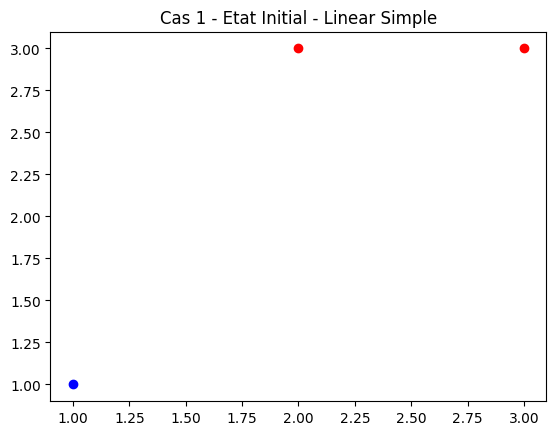

<Figure size 640x480 with 0 Axes>

In [193]:
X = np.array([
    [1, 1],
    [2, 3],
    [3, 3]
], dtype=np.float64)

Y = np.array([
    1,
    -1,
    -1
], dtype=np.float64)

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.title("Cas 1 - Etat Initial - Linear Simple")
plt.show()
plt.clf()


#### Initialisation du Model

In [194]:
layers = (c_int * 2)(2, 1)

nb_layers     = 2
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample          = 3
nb_data_per_sample = 2

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y
)

#### Entrainement

In [195]:
epochs = 100
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

#### Etat de sortie

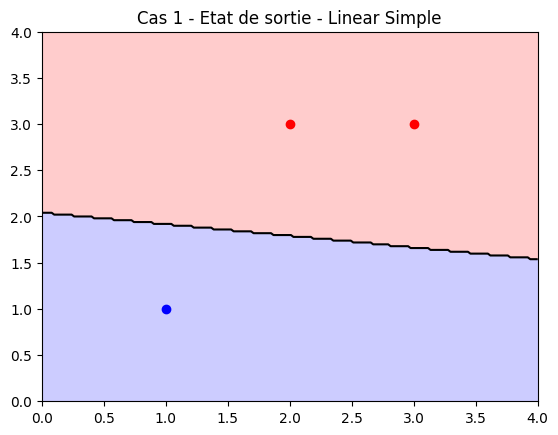

<Figure size 640x480 with 0 Axes>

In [196]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
nb_grid     = grid_points.shape[0]

grid_input = (c_double * (nb_grid * nb_data_per_sample))(
    *grid_points.flatten()
)

grid_pred_ptr = lib.predict(model, grid_input, nb_grid, nb_data_per_sample, 1)
grid_preds    = np.array([grid_pred_ptr[i] for i in range(nb_grid)])
grid_labels   = np.where(grid_preds >= 0, 1, -1).reshape(xx.shape)

lib.free_p(grid_pred_ptr)

plt.contourf(xx, yy, grid_labels, alpha=0.2, levels=[-2, 0, 2], colors=['red', 'blue'])
plt.contour(xx, yy, grid_labels, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', zorder=5)
plt.title("Cas 1 - Etat de sortie - Linear Simple")
plt.show()
plt.clf()

#### Courbe de Loss

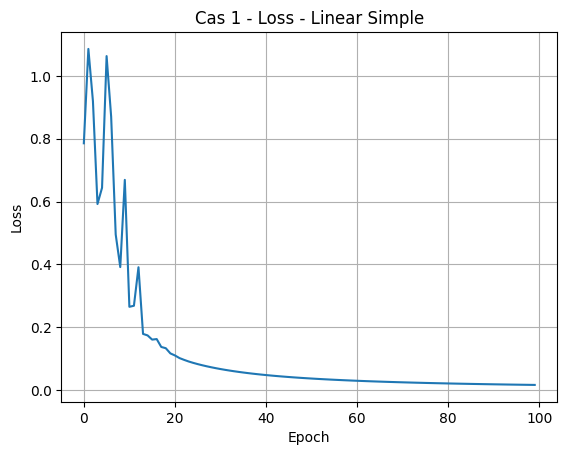

In [197]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cas 1 - Loss - Linear Simple")
plt.grid()
plt.show()

lib.free_p(pred_ptr)
lib.free_pmc(model)


### Cas 2 - Lineaire Multiple

### Cas 3 - XOR

### Cas 4 - Cross

### Cas 5 - Multi Linear 3 Class

### Cas 6 - Multi Cross

## Regression

### Cas 7 - Linear Simple 2d

### Cas 8 - Non Linear Simple 2d

### Cas 9 - Linear Simple 3d

### Cas 10 - Linear Tricky 3d

### Cas 11 - Non linear Simple 3d

### Cas 12 - Part Data Set